In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from readrbdata import load

import matplotlib.pyplot as plt
from fittingutils import *
%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)
len(sat.time), len(uns.time)

(13269, 13246)

In [4]:
uns_data_interp = np.interp(sat.time, uns.time, uns.signal)
diff_signal = sat.signal - uns_data_interp

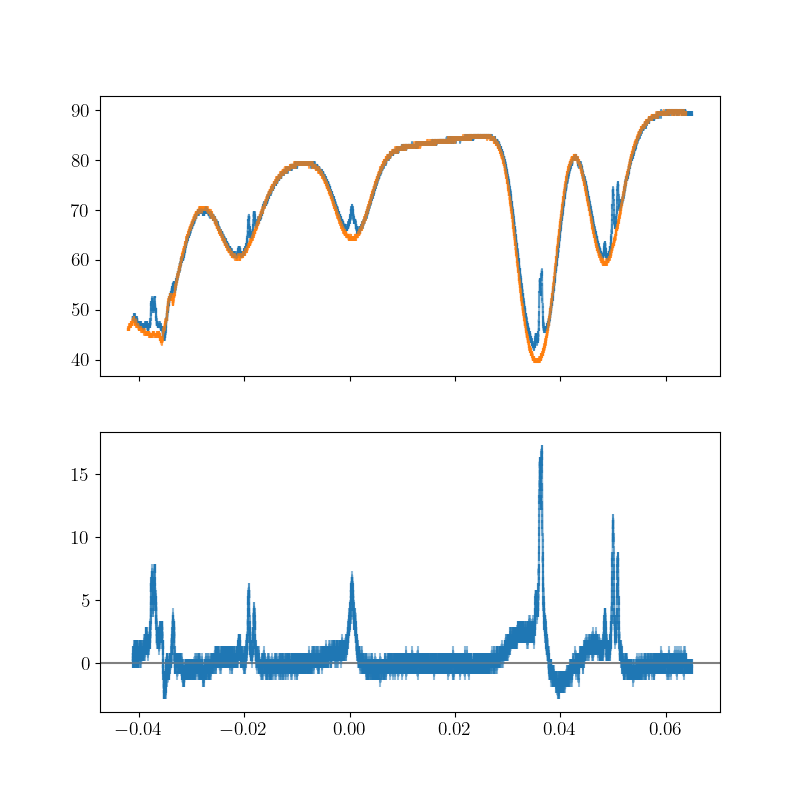

In [5]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(8, 8))

sig_ax.errorbar(sat.time, sat.signal, yerr=0.25, alpha=0.5)
sig_ax.errorbar(uns.time, uns.signal, yerr=0.25, alpha=0.5)

diff_ax.errorbar(sat.time, diff_signal, yerr=np.sqrt(2)*0.25, alpha=0.5)
diff_ax.axhline(0., color="gray")

In [58]:
def fit_spike(x_low, x_high, cluster_n):
    # MAKE PLOTS
    fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(20, 10))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = sat.time[spidx]
    y = diff_signal[spidx]

    baseline_guess = np.quantile(y, 0.3)

    p0 = [
        x[np.argmax(diff_signal[spidx])],
        Lorentzian.guess_gamma(x, y),
        np.max(y) - baseline_guess,
        baseline_guess
    ]
    print(f"{p0 = }")

    guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_data_ax.plot(x, Lorentzian(x, *p0), zorder=10, color='blue')

    guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3])/2, (p0[2] + p0[3])/2], color='green', alpha=0.5, label='FWHM guess')
    guess_data_ax.axhline(p0[2] + p0[3], label='amplitude guess', c='red', alpha=0.5)
    guess_data_ax.axhline(p0[3], label='baseline guess', c='red', alpha=0.5)

    guess_data_ax.set_title('Fit Initial Guess')
    guess_data_ax.set_ylabel('Voltage (V)')
    guess_data_ax.legend()

    residuals = Lorentzian(x, *p0) - y

    guess_res_ax.axhline(0., color='gray')
    guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(Lorentzian, x, y, p0, np.sqrt(2)*0.25)
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
    fit_data_ax.plot(x, Lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
    for fit_sample in random_fit_samples:
        fit_data_ax.plot(x, Lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
    fit_data_ax.plot(x, Lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')
    
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    fit_data_ax.set_title('Resulting Fit')

    residuals = Lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    for fit_sample in random_fit_samples:
        fit_res_ax.plot(x, Lorentzian(x, *fit_sample) - Lorentzian(x, *fit_params), c='orange')

    fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')
    np.sqrt(np.diag(cov))
    this_spike = {
        "center_time": fit_params[0],
        "e_center_time": np.sqrt(np.diag(cov))[0],
        "amplitude": fit_params[2],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")

p0 = [0.000472, 0.000288, 7.0, 0.0]
fit params:
[4.41450143e-04 5.57504278e-04 5.89149036e+00 1.08448792e-03]
cov:
[[ 4.46974596e-11  1.00335658e-14  9.13029480e-12 -3.33678656e-11]
 [ 1.00335658e-14  1.10389518e-10 -4.62578923e-07 -6.28408869e-08]
 [ 9.13029480e-12 -4.62578923e-07  4.99870178e-03 -3.04854483e-05]
 [-3.33678656e-11 -6.28408869e-08 -3.04854483e-05  1.88920209e-04]]
this_spike = {'center_time': 0.0004414501431866704, 'e_center_time': 6.685615874337352e-06, 'amplitude': 5.891490363275234, 'cluster_id': 1}
SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE
len(spike_data) = 2


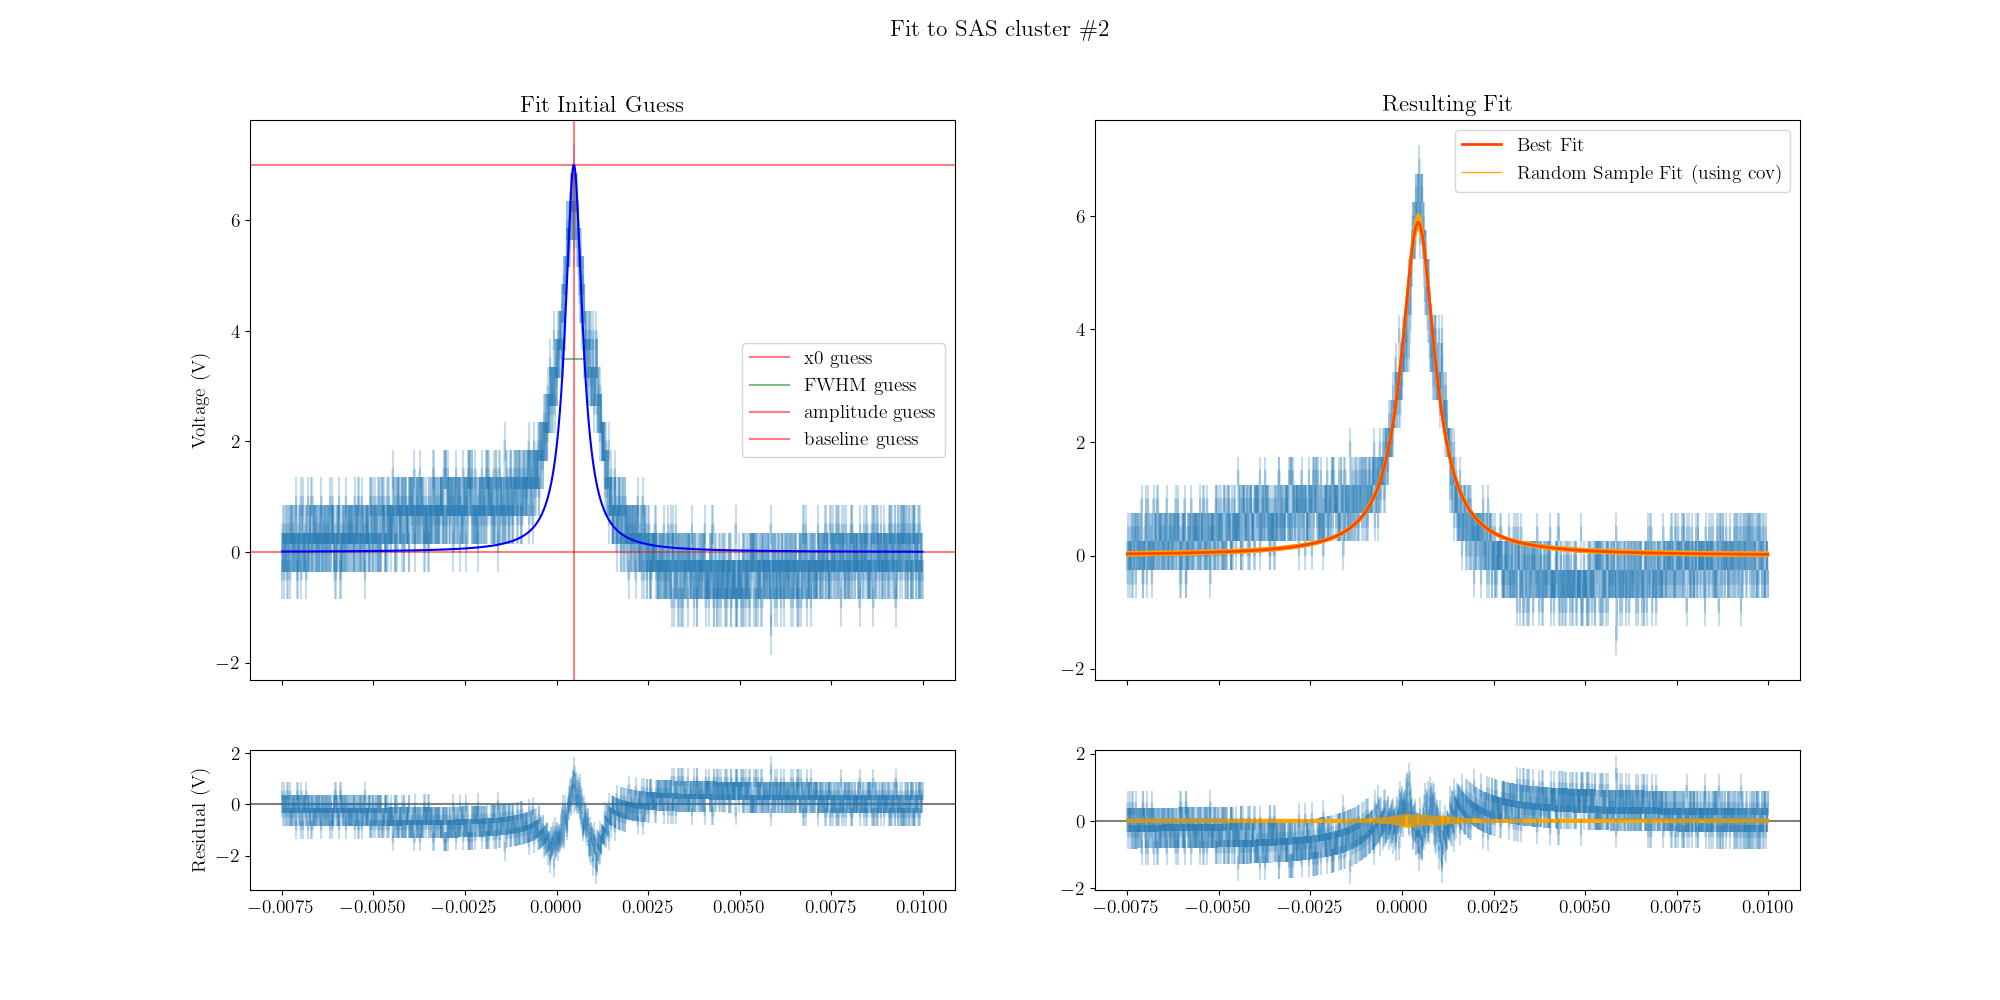

In [59]:
fit_spike(-.0075, 0.01, 1)